<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/Computer_Vision_with_PyTorch_Excercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises. Solution


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

- Агросектор - дрони з комп’ютерним зором для моніторингу полів (DroneUA, AgriEye, AgriLab, деякі агрохолдинги (Kernel, MHP) впроваджують власні CV-системи для контролю якості).

- Безпека, оборона та відеоаналітика (Defense & Security) - з огляду на війну у нас це одна з найрозвиненіших сфер комп’ютерного зору (Defence Tech стартапи (Skydio Ukraine, DevDroid, Infocom, LimpidArmor, системи для безпеки міст (розпізнавання порушень, номерів авто, підозрілих об'єктів))

- Рітейл та e-commerce - автоматичний контроль на касах (self-checkout), виявлення крадіжок (loss prevention), аналіз поведінки покупців, комп’ютерне сортування товарів і підрахунок залишків на складах, оптимізація логістики і роботизація складів (Rozetka, Silpo, ATB - відеоаналітика та контроль якості, Нова Пошта - сортування посилок та автоматизація складів через CV, Ajax Systems - CV-системи для охоронних камер).


## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

- Після виконання вправи я зрозуміла, як саме згорткова нейронна мережа поступово "читає" зображення. На ранніх шарах CNN виділяє лише прості контури й базові текстури, на середніх - починає помічати комбінації ліній і частини об’єктів, а на глибших - формує високорівневі абстракції, що відповідають цілим елементам зображення. Я побачила, що з кожним наступним шаром зменшується деталізація, але збільшується семантична насиченість ознак. Також стало зрозуміло, що різні фільтри активуються для різних частин зображення, тобто мережа навчається фокусуватися саме на важливих ділянках.

## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [ ]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 21.2 MB/s eta 0:00:00


In [ ]:
#Імпорти
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn
import time
import numpy as np
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix


In [ ]:
# Трансформація: перетворюємо зображення в тензор
transform = transforms.ToTensor()

# Завантаження даних
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.80MB/s]


In [ ]:
# Кількість елементів
print("Кількість елементів у train:", len(train_dataset))
print("Кількість елементів у test :", len(test_dataset))

Кількість елементів у train: 60000
Кількість елементів у test : 10000


In [ ]:
# Формат (розмірності) картинки
image, label = train_dataset[0]
print("\nФормат одного зображення:", image.shape)


Формат одного зображення: torch.Size([1, 28, 28])


In [ ]:
# Унікальні класи в наборі даних
classes = sorted(set(train_dataset.targets.tolist()))
print("\nКласи у наборі:", classes)


Класи у наборі: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

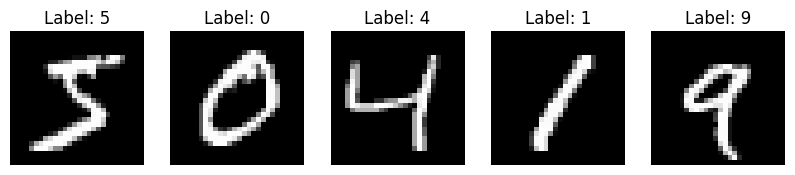

In [ ]:
# Кількість зразків для показу
num_samples = 5

plt.figure(figsize=(10, 2))

for i in range(num_samples):
    image, label = train_dataset[i]

    # Перетворюємо тензор у формат для plt
    img = image.squeeze()  # робимо 28x28 замість (1x28x28)

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [ ]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Візьмемо один батч
images, labels = next(iter(train_loader))

print("Форма batch images:", images.shape)
print("Форма batch labels:", labels.shape)

Форма batch images: torch.Size([32, 1, 28, 28])
Форма batch labels: torch.Size([32])


1. Форма batch images: torch.Size([32, 1, 28, 28])

CNN у PyTorch очікує саме такий формат:

`[batch_size, channels, height, width]`.

- 32 - кількість зображень у батчі

- 1 - один канал (чорно-біле зображення)

- 28 × 28 — розмір кожного зображення

2. Форма batch labels: torch.Size([32])

Це просто вектор з 32 елементами (32 зображень - кожне зображення має одну мітку (цифра 0–9), тому ми маємо 32 числові значення)

## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [ ]:
class ModelV2(nn.Module):

    def __init__(self, input_channels: int = 1, num_classes: int = 10):
        super().__init__()

        # Блок згорток 1
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_channels, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 28x28 -> 14x14
        )

        # Блок згорток 2
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 14x14 -> 7x7
        )

        # Класифікатор
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # 16 * 7 * 7 = 784
            nn.Linear(in_features=16*7*7, out_features=num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [ ]:
#Функція навчання з вимірюванням часу
def train_for_n_epochs(model, train_loader, device, epochs: int = 5):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    start_time = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"[{device}] Epoch {epoch+1}/{epochs}, loss: {epoch_loss:.4f}")

    end_time = time.perf_counter()
    total_time = end_time - start_time
    print(f"\n✅ Загальний час навчання на {device}: {total_time:.2f} секунд\n")

    return total_time

In [ ]:
# Навчання на CPU
device_cpu = torch.device("cpu")
cpu_time = train_for_n_epochs(ModelV2(), train_loader, device_cpu, epochs=5)

[cpu] Epoch 1/5, loss: 0.1835
[cpu] Epoch 2/5, loss: 0.0622
[cpu] Epoch 3/5, loss: 0.0471
[cpu] Epoch 4/5, loss: 0.0389
[cpu] Epoch 5/5, loss: 0.0331

✅ Загальний час навчання на cpu: 144.55 секунд



In [ ]:
# Навчання на GPU
model_gpu = ModelV2()
device_gpu = torch.device("cuda")
gpu_time = train_for_n_epochs(model_gpu, train_loader, device_gpu, epochs=5)

[cuda] Epoch 1/5, loss: 0.2003
[cuda] Epoch 2/5, loss: 0.0627
[cuda] Epoch 3/5, loss: 0.0468
[cuda] Epoch 4/5, loss: 0.0373
[cuda] Epoch 5/5, loss: 0.0322

✅ Загальний час навчання на cuda: 56.25 секунд



## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_gpu.to(device)
model_gpu.eval()  # режим оцінки

# Беремо один batch із тестових даних
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Робимо прогнози
with torch.no_grad():
    outputs = model_gpu(images)
    preds = outputs.argmax(dim=1)


In [ ]:
model_name = model_gpu.__class__.__name__

criterion = torch.nn.CrossEntropyLoss()

test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_gpu(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

model_loss = test_loss / len(test_loader)
model_acc = correct / total

print("model_name:", model_name)
print("model_loss:", model_loss)
print("model_acc:", model_acc)

model_name: ModelV2
model_loss: 0.03463069895263698
model_acc: 0.9882


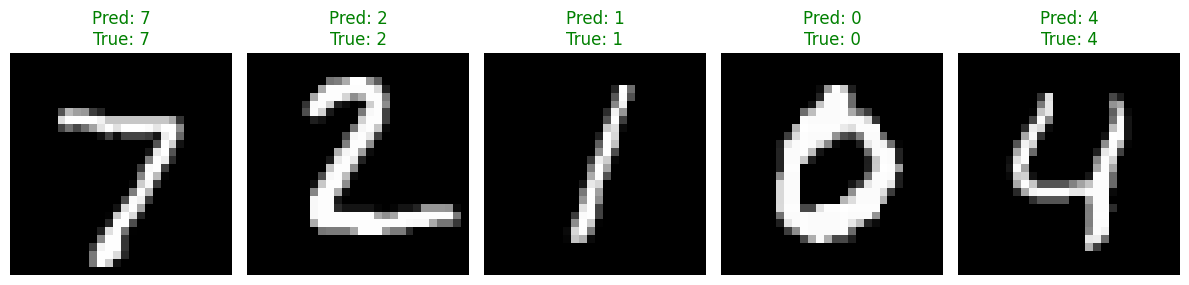

In [ ]:
# Візуалізуємо перші 5 прикладів
num_samples = 5
plt.figure(figsize=(12, 3))

for i in range(num_samples):
    img = images[i].cpu().squeeze(0)  # (1, 28, 28) -> (28, 28)
    true_label = labels[i].item()
    pred_label = preds[i].item()

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap="gray")

    # колір підпису: зелений, якщо правильно, інакше червоний
    color = "green" if true_label == pred_label else "red"
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_gpu(images)              # [batch_size, 10]
        preds = outputs.argmax(dim=1)            # [batch_size]

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

# Об'єднуємо всі батчі в один тензор
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

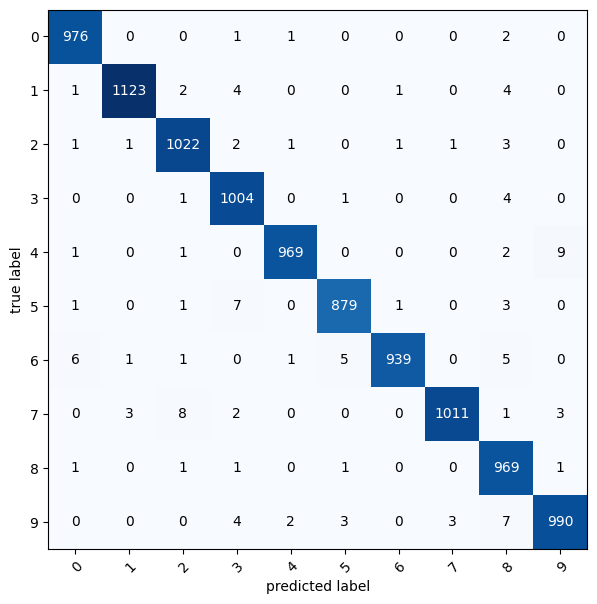

In [ ]:
# Створюємо ConfusionMatrix від torchmetrics
num_classes = 10
class_names = [str(i) for i in range(num_classes)]

confmat = ConfusionMatrix(num_classes=num_classes, task="multiclass")

confmat_tensor = confmat(preds=all_preds, target=all_labels)

# Побудова матриці
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)
plt.show()

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

In [ ]:
misclassified_images = []
misclassified_true = []
misclassified_pred = []

# 1. Збираємо помилкові приклади
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_gpu(images)
        preds = outputs.argmax(dim=1)

        # маска помилкових передбачень
        wrong_mask = preds != labels

        if wrong_mask.any():
            wrong_images = images[wrong_mask]
            wrong_labels = labels[wrong_mask]
            wrong_preds = preds[wrong_mask]

            for img, true_lab, pred_lab in zip(wrong_images, wrong_labels, wrong_preds):
                misclassified_images.append(img.cpu())
                misclassified_true.append(true_lab.cpu().item())
                misclassified_pred.append(pred_lab.cpu().item())

                if len(misclassified_images) >= 9:
                    break

        if len(misclassified_images) >= 9:
            break

print(f"Знайдено {len(misclassified_images)} помилкових прикладів.")


Знайдено 9 помилкових прикладів.


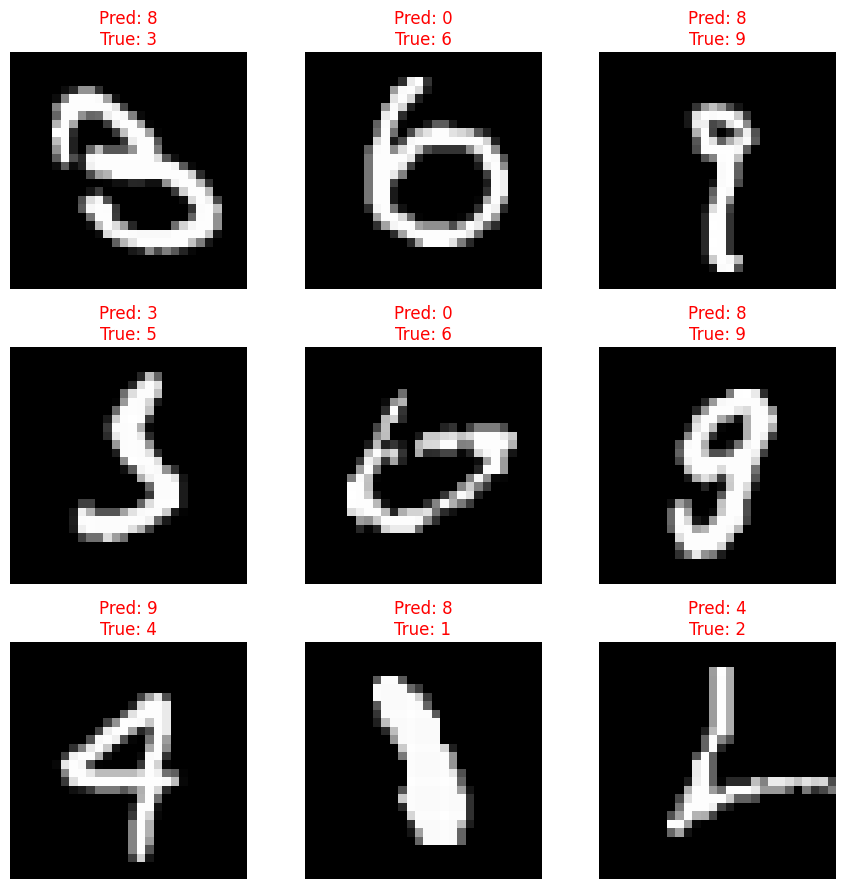

In [ ]:
# Візуалізація перших 9 помилок
num_examples = min(9, len(misclassified_images))

plt.figure(figsize=(9, 9))
for i in range(num_examples):
    img = misclassified_images[i].squeeze(0)  # (1, 28, 28) -> (28, 28)
    true_label = misclassified_true[i]
    pred_label = misclassified_pred[i]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color="red")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Спостереження**

Після візуального аналізу помилкових передбачень можна зробити висновок, що більшість неправильних класифікацій пов’язані не стільки з недоліками моделі, скільки з особливостями самих даних. Частина зображень у MNIST є нечіткими, спотвореними або схожими на інші цифри настільки, що навіть людина може помилитися. Хоча модель можна додатково покращити шляхом збільшення кількості фільтрів або застосування data augmentation, значна частина помилок є об’єктивними помилками даних, а не моделі.

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [ ]:
# Створюємо випадковий тензор [batch=1, channels=3, H=64, W=64]
x = torch.randn(1, 3, 64, 64)

# Різні варіанти kernel_size
conv_3 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3)   # маленьке ядро
conv_5 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5)   # середнє
conv_7 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=7)   # велике

y3 = conv_3(x)
y5 = conv_5(x)
y7 = conv_7(x)

print("kernel_size=3 →", y3.shape)
print("kernel_size=5 →", y5.shape)
print("kernel_size=7 →", y7.shape)

kernel_size=3 → torch.Size([1, 8, 62, 62])
kernel_size=5 → torch.Size([1, 8, 60, 60])
kernel_size=7 → torch.Size([1, 8, 58, 58])


torch.Size([1, 1, 64, 64]) torch.Size([1, 1, 64, 64]) torch.Size([1, 1, 64, 64])


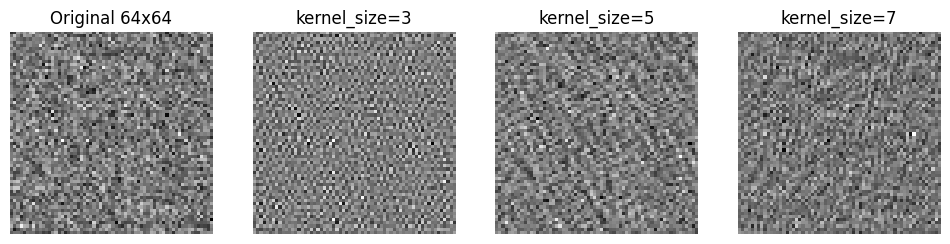

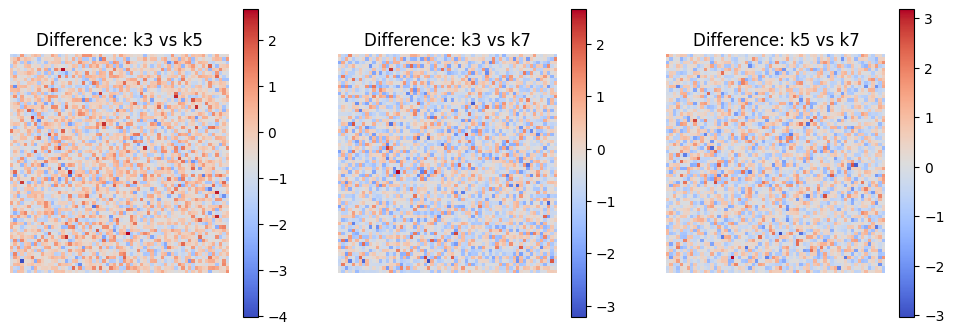

In [ ]:
# 1. Випадкове зображення
x = torch.randn(1, 1, 64, 64)

# 2. Convolution layers з padding, щоб вихід був 64x64
conv3 = nn.Conv2d(1, 1, kernel_size=3, padding=1)  # (64 - 3 + 2*1) + 1 = 64
conv5 = nn.Conv2d(1, 1, kernel_size=5, padding=2)  # (64 - 5 + 2*2) + 1 = 64
conv7 = nn.Conv2d(1, 1, kernel_size=7, padding=3)  # (64 - 7 + 2*3) + 1 = 64

y3 = conv3(x)
y5 = conv5(x)
y7 = conv7(x)

print(y3.shape, y5.shape, y7.shape)  # тепер усі: [1, 1, 64, 64]

# 3. Візуалізація самих карт
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(x.squeeze().detach().numpy(), cmap="gray")
plt.title("Original 64x64")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(y3.squeeze().detach().numpy(), cmap="gray")
plt.title("kernel_size=3")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(y5.squeeze().detach().numpy(), cmap="gray")
plt.title("kernel_size=5")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(y7.squeeze().detach().numpy(), cmap="gray")
plt.title("kernel_size=7")
plt.axis("off")

plt.show()

# 4. Візуалізація різниці між картами (тепер розміри збігаються)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow((y3 - y5).squeeze().detach().numpy(), cmap="coolwarm")
plt.title("Difference: k3 vs k5")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow((y3 - y7).squeeze().detach().numpy(), cmap="coolwarm")
plt.title("Difference: k3 vs k7")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow((y5 - y7).squeeze().detach().numpy(), cmap="coolwarm")
plt.title("Difference: k5 vs k7")
plt.colorbar()
plt.axis("off")

plt.show()

**Спостереження**

Зі збільшенням kernel_size фільтр бачить більший контекст, але втрачає локальні деталі. Маленькі ядра зберігають текстуру і реагують на дрібні патерни, тоді як великі ядра роблять карту ознак більш гладкою і реагують на глобальні структури. Різницеві heatmaps підтверджують, що великі ядра пригнічують високочастотні зміни, залишаючи тільки великі форми.